# Heart Sound Analysis
วิเคราะห์ไฟล์เสียงหัวใจใน dataset เพื่อเลือก sample ที่เหมาะสมสำหรับ app

**metrics ที่คำนวณ:**
- **RMS** — ความดัง (Root Mean Square energy)
- **Peak** — แอมพลิจูดสูงสุด
- **dBFS** — ความดังในหน่วย dB (0 dBFS = เต็ม scale)
- **SNR** — Signal-to-Noise Ratio (ยิ่งสูง = noise น้อย)
- **Noise Floor** — พลังงานของ noise ในช่วงเงียบ
- **Spectral Centroid** — ความถี่ศูนย์กลาง (Hz)
- **Low Freq Energy %** — พลังงานในย่าน 20-500 Hz (เสียงหัวใจ)

In [2]:
# Install dependencies ถ้ายังไม่มี
!pip install librosa numpy pandas matplotlib scipy soundfile seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 54.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [librosa]0/13 [numba]te]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Path ไปยัง Heart_sound folder
HEART_SOUND_DIR = Path('/Users/frank/Vscode/Flutter_webRTC_Heart/Heart_sound')

print(f'Heart sound directory: {HEART_SOUND_DIR}')
print(f'Exists: {HEART_SOUND_DIR.exists()}')

# ตั้งค่า style
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid', palette='husl')

Heart sound directory: /Users/frank/Vscode/Flutter_webRTC_Heart/Heart_sound
Exists: True


In [4]:
# ==================== Functions ====================

def compute_snr(y, sr, noise_duration=0.3):
    """
    ประมาณ SNR โดยเอา noise floor จาก frame ที่เงียบที่สุด
    แบ่ง signal เป็น frame 50ms แล้วหาค่า RMS
    noise = mean ของ 20% frame ที่เบาที่สุด
    signal = mean ของ 20% frame ที่ดังที่สุด
    """
    frame_len = int(sr * 0.05)  # 50ms
    hop = frame_len // 2
    frames = librosa.util.frame(y, frame_length=frame_len, hop_length=hop)
    rms_frames = np.sqrt(np.mean(frames**2, axis=0))
    rms_frames = rms_frames[rms_frames > 0]
    if len(rms_frames) < 4:
        return 0.0
    n = max(1, len(rms_frames) // 5)
    noise_rms = np.mean(np.sort(rms_frames)[:n])
    signal_rms = np.mean(np.sort(rms_frames)[-n:])
    if noise_rms < 1e-10:
        return 60.0  # เงียบมาก = SNR สูงมาก
    snr_db = 20 * np.log10(signal_rms / noise_rms)
    return snr_db


def compute_noise_floor(y, sr):
    """คำนวณ noise floor ในหน่วย dBFS"""
    frame_len = int(sr * 0.05)
    hop = frame_len // 2
    frames = librosa.util.frame(y, frame_length=frame_len, hop_length=hop)
    rms_frames = np.sqrt(np.mean(frames**2, axis=0))
    rms_frames = rms_frames[rms_frames > 0]
    if len(rms_frames) == 0:
        return -96.0
    n = max(1, len(rms_frames) // 5)
    noise_rms = np.mean(np.sort(rms_frames)[:n])
    if noise_rms < 1e-10:
        return -96.0
    return 20 * np.log10(noise_rms)


def compute_low_freq_energy(y, sr, low=20, high=500):
    """% พลังงานในย่านความถี่ 20-500 Hz (เสียงหัวใจ)"""
    fft = np.abs(np.fft.rfft(y))**2
    freqs = np.fft.rfftfreq(len(y), 1/sr)
    total = np.sum(fft)
    if total < 1e-10:
        return 0.0
    heart_mask = (freqs >= low) & (freqs <= high)
    heart_energy = np.sum(fft[heart_mask])
    return (heart_energy / total) * 100


def analyze_wav(filepath):
    """วิเคราะห์ไฟล์ WAV ไฟล์เดียว คืนค่า dict ของ metrics"""
    try:
        y, sr = librosa.load(str(filepath), sr=None, mono=True)
        if len(y) == 0:
            return None

        rms = np.sqrt(np.mean(y**2))
        peak = np.max(np.abs(y))
        dbfs = 20 * np.log10(rms + 1e-10)
        peak_dbfs = 20 * np.log10(peak + 1e-10)
        snr = compute_snr(y, sr)
        noise_floor = compute_noise_floor(y, sr)
        low_freq_pct = compute_low_freq_energy(y, sr)
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        duration = len(y) / sr
        zero_crossing = np.mean(librosa.feature.zero_crossing_rate(y))

        return {
            'rms': rms,
            'peak': peak,
            'dbfs': dbfs,
            'peak_dbfs': peak_dbfs,
            'snr_db': snr,
            'noise_floor_db': noise_floor,
            'low_freq_pct': low_freq_pct,
            'spectral_centroid_hz': spectral_centroid,
            'duration_s': duration,
            'sample_rate': sr,
            'zero_crossing_rate': zero_crossing,
        }
    except Exception as e:
        print(f'Error: {filepath.name}: {e}')
        return None

print('Functions loaded ✓')

Functions loaded ✓


In [5]:
# ==================== Load all WAV files ====================

records = []

for folder in sorted(HEART_SOUND_DIR.iterdir()):
    if not folder.is_dir():
        continue
    
    # แยก position และ variant จากชื่อ folder (เช่น Aortic_0)
    parts = folder.name.rsplit('_', 1)
    if len(parts) != 2:
        continue
    position, variant = parts[0], parts[1]

    for wav_file in sorted(folder.glob('*.wav')):
        band = wav_file.stem  # Original, Band1, Band2, Band3
        # ข้าม "Band2 3 dB" (duplicate)
        if '3 dB' in band:
            continue

        print(f'Analyzing: {folder.name}/{wav_file.name}', end='\r')
        metrics = analyze_wav(wav_file)
        if metrics:
            metrics.update({
                'position': position,
                'variant': int(variant),
                'band': band,
                'folder': folder.name,
                'filename': wav_file.name,
                'filepath': str(wav_file),
            })
            records.append(metrics)

df = pd.DataFrame(records)
df = df.sort_values(['position', 'variant', 'band']).reset_index(drop=True)

print(f'\n\nLoaded {len(df)} files from {df["folder"].nunique()} folders')
print(f'Positions: {sorted(df["position"].unique())}')
print(f'Bands: {sorted(df["band"].unique())}')
df.head()

Analyzing: Tricuspid_5/Original.wavwav

Loaded 93 files from 22 folders
Positions: ['Aortic', 'Mitral', 'Pulmonary', 'Tricuspid']
Bands: ['Band1', 'Band2', 'Band2 10 dB', 'Band2 6 dB', 'Band2 copy', 'Band3', 'Original']


,rms,peak,dbfs,peak_dbfs,snr_db,noise_floor_db,low_freq_pct,spectral_centroid_hz,duration_s,sample_rate,zero_crossing_rate,position,variant,band,folder,filename,filepath
0,0.017968,0.174072,-34.910198,-15.185409,20.484505,-50.165260,99.962631,1635.745036,14.968889,44100,0.008713,Aortic,0,Band1,Aortic_0,Band1.wav,/Users/frank/Vscode/Flutter_webRTC_Heart/Heart...
1,0.018520,0.181000,-34.647064,-14.846440,18.643263,-47.984947,99.706993,1112.755079,14.968889,44100,0.007728,Aortic,0,Band2,Aortic_0,Band2.wav,/Users/frank/Vscode/Flutter_webRTC_Heart/Heart...
2,0.032762,0.243134,-29.692717,-12.283102,14.692944,-39.288799,81.971046,548.987347,14.968889,44100,0.002894,Aortic,0,Band3,Aortic_0,Band3.wav,/Users/frank/Vscode/Flutter_webRTC_Heart/Heart...
3,0.032762,0.243134,-29.692717,-12.283102,14.692950,-39.288807,81.971054,549.328846,14.968889,44100,0.002812,Aortic,0,Original,Aortic_0,Original.wav,/Users/frank/Vscode/Flutter_webRTC_Heart/Heart...
4,0.050757,0.597290,-25.890034,-4.476295,17.117897,-37.738853,99.959122,513.970216,14.968889,44100,0.003835,Aortic,1,Band1,Aortic_1,Band1.wav,/Users/frank/Vscode/Flutter_webRTC_Heart/Heart...


In [6]:
# ==================== Rankings ====================

# กรองเฉพาะ Original.wav
df_orig = df[df['band'] == 'Original'].copy()

print('=' * 60)
print('RANKINGS — Original.wav files only')
print('=' * 60)

def show_ranking(df, col, label, ascending=True, n=5):
    ranked = df.nsmallest(n, col) if ascending else df.nlargest(n, col)
    print(f'\n🏆 {label} ({'น้อย→มาก' if ascending else 'มาก→น้อย'})')
    print('-' * 50)
    for i, (_, row) in enumerate(ranked.iterrows(), 1):
        print(f'  {i}. {row["folder"]:20s}  {col}: {row[col]:8.2f}')

# ดังสุด / เบาสุด
show_ranking(df_orig, 'dbfs', 'ดังสุด (RMS dBFS)', ascending=False)
show_ranking(df_orig, 'dbfs', 'เบาสุด (RMS dBFS)', ascending=True)

# Peak
show_ranking(df_orig, 'peak_dbfs', 'Peak สูงสุด', ascending=False)

# SNR
show_ranking(df_orig, 'snr_db', 'SNR สูงสุด (noise น้อยสุด)', ascending=False)
show_ranking(df_orig, 'snr_db', 'SNR ต่ำสุด (noise เยอะสุด)', ascending=True)

# Noise floor
show_ranking(df_orig, 'noise_floor_db', 'Noise Floor ต่ำสุด (สะอาดสุด)', ascending=True)
show_ranking(df_orig, 'noise_floor_db', 'Noise Floor สูงสุด (noisy สุด)', ascending=False)

# Low freq energy (เสียงหัวใจ 20-500 Hz)
show_ranking(df_orig, 'low_freq_pct', 'Low Freq Energy สูงสุด (เสียงหัวใจมากสุด)', ascending=False)
show_ranking(df_orig, 'low_freq_pct', 'Low Freq Energy ต่ำสุด (เสียงหัวใจน้อยสุด)', ascending=True)

RANKINGS — Original.wav files only

🏆 ดังสุด (RMS dBFS) (มาก→น้อย)
--------------------------------------------------
  1. Pulmonary_2           dbfs:   -13.80
  2. Mitral_2              dbfs:   -14.55
  3. Tricuspid_0           dbfs:   -15.48
  4. Tricuspid_4           dbfs:   -16.25
  5. Mitral_3              dbfs:   -16.62

🏆 เบาสุด (RMS dBFS) (น้อย→มาก)
--------------------------------------------------
  1. Aortic_0              dbfs:   -29.69
  2. Pulmonary_5           dbfs:   -26.14
  3. Mitral_5              dbfs:   -25.48
  4. Tricuspid_5           dbfs:   -24.46
  5. Tricuspid_1           dbfs:   -22.01

🏆 Peak สูงสุด (มาก→น้อย)
--------------------------------------------------
  1. Mitral_2              peak_dbfs:     0.00
  2. Pulmonary_2           peak_dbfs:     0.00
  3. Tricuspid_4           peak_dbfs:    -0.00
  4. Mitral_3              peak_dbfs:    -0.01
  5. Tricuspid_0           peak_dbfs:    -0.04

🏆 SNR สูงสุด (noise น้อยสุด) (มาก→น้อย)
--------------------------

In [7]:
# ==================== Summary Table ====================

summary = df_orig.groupby(['position', 'variant']).agg(
    dbfs=('dbfs', 'mean'),
    snr_db=('snr_db', 'mean'),
    noise_floor_db=('noise_floor_db', 'mean'),
    low_freq_pct=('low_freq_pct', 'mean'),
    spectral_centroid_hz=('spectral_centroid_hz', 'mean'),
    duration_s=('duration_s', 'mean'),
).round(2).reset_index()

# เพิ่ม label variant 0=ปกติ
summary['label'] = summary.apply(
    lambda r: f"{r['position']}_{r['variant']} {'(ปกติ)' if r['variant']==0 else ''}", axis=1
)

print('Summary Table — Original WAV')
display(summary[['label','dbfs','snr_db','noise_floor_db','low_freq_pct','spectral_centroid_hz','duration_s']]\
    .rename(columns={
        'dbfs': 'dBFS',
        'snr_db': 'SNR (dB)',
        'noise_floor_db': 'Noise Floor (dB)',
        'low_freq_pct': 'Low Freq %',
        'spectral_centroid_hz': 'Centroid (Hz)',
        'duration_s': 'Duration (s)',
    }).to_string(index=False))

Summary Table — Original WAV


'             label       dBFS  SNR (dB)  Noise Floor (dB)  Low Freq %  Centroid (Hz)  Duration (s)\n   Aortic_0 (ปกติ) -29.690001 14.690000        -39.290001   81.970001         549.33         14.97\n         Aortic_1  -21.270000 11.890000        -28.700001   81.849998         242.70         14.97\n         Aortic_2  -17.830000 11.620000        -25.270000   80.120003         283.13         15.07\n         Aortic_3  -20.559999 16.809999        -32.110001   83.349998         156.84         15.28\n         Aortic_4  -18.459999 24.559999        -36.849998   89.629997         161.96         15.02\n         Aortic_5  -20.629999 18.410000        -33.730000   79.599998         145.00         14.96\n   Mitral_0 (ปกติ) -17.709999 16.520000        -28.719999   83.550003         209.54         14.96\n         Mitral_2  -14.550000 16.530001        -26.309999   64.639999         388.43         15.27\n         Mitral_3  -16.620001 19.879999        -31.040001   85.110001         139.72         15.02\

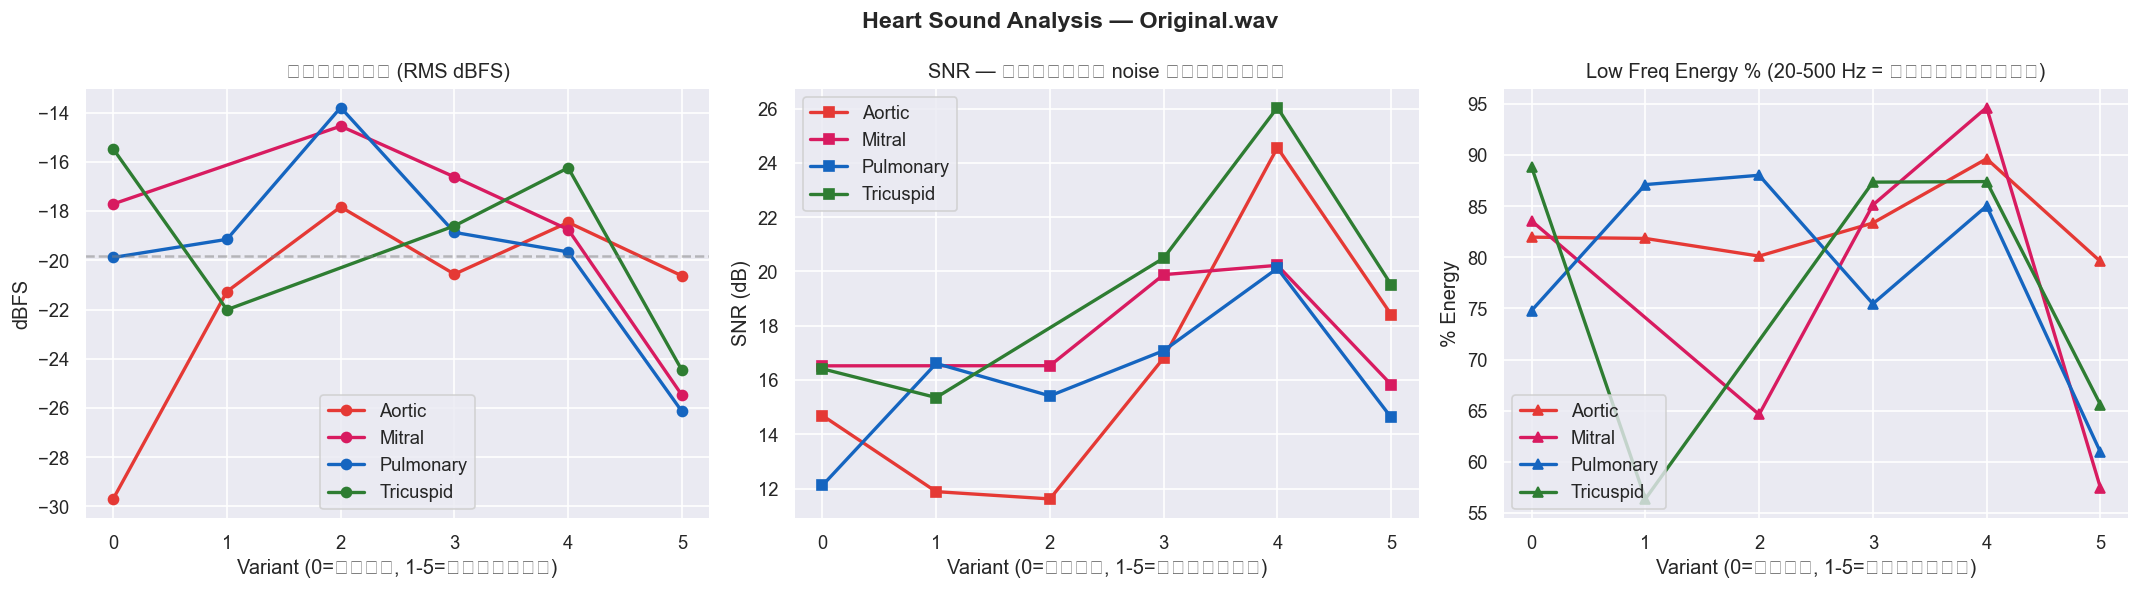

Saved: heart_sound_metrics.png


In [8]:
# ==================== Visualization 1: dBFS + SNR heatmap ====================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Heart Sound Analysis — Original.wav', fontsize=14, fontweight='bold')

positions = sorted(df_orig['position'].unique())
colors = ['#E53935', '#D81B60', '#1565C0', '#2E7D32']

# --- Plot 1: RMS dBFS per position/variant ---
ax = axes[0]
for i, pos in enumerate(positions):
    sub = df_orig[df_orig['position'] == pos].sort_values('variant')
    ax.plot(sub['variant'], sub['dbfs'], 'o-', label=pos, color=colors[i], linewidth=2)
ax.set_title('ความดัง (RMS dBFS)')
ax.set_xlabel('Variant (0=ปกติ, 1-5=ผิดปกติ)')
ax.set_ylabel('dBFS')
ax.legend()
ax.axhline(y=df_orig['dbfs'].mean(), color='gray', linestyle='--', alpha=0.5, label='mean')

# --- Plot 2: SNR per position/variant ---
ax = axes[1]
for i, pos in enumerate(positions):
    sub = df_orig[df_orig['position'] == pos].sort_values('variant')
    ax.plot(sub['variant'], sub['snr_db'], 's-', label=pos, color=colors[i], linewidth=2)
ax.set_title('SNR — ยิ่งสูง noise น้อยกว่า')
ax.set_xlabel('Variant (0=ปกติ, 1-5=ผิดปกติ)')
ax.set_ylabel('SNR (dB)')
ax.legend()

# --- Plot 3: Low Freq Energy % ---
ax = axes[2]
for i, pos in enumerate(positions):
    sub = df_orig[df_orig['position'] == pos].sort_values('variant')
    ax.plot(sub['variant'], sub['low_freq_pct'], '^-', label=pos, color=colors[i], linewidth=2)
ax.set_title('Low Freq Energy % (20-500 Hz = เสียงหัวใจ)')
ax.set_xlabel('Variant (0=ปกติ, 1-5=ผิดปกติ)')
ax.set_ylabel('% Energy')
ax.legend()

plt.tight_layout()
plt.savefig('heart_sound_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heart_sound_metrics.png')

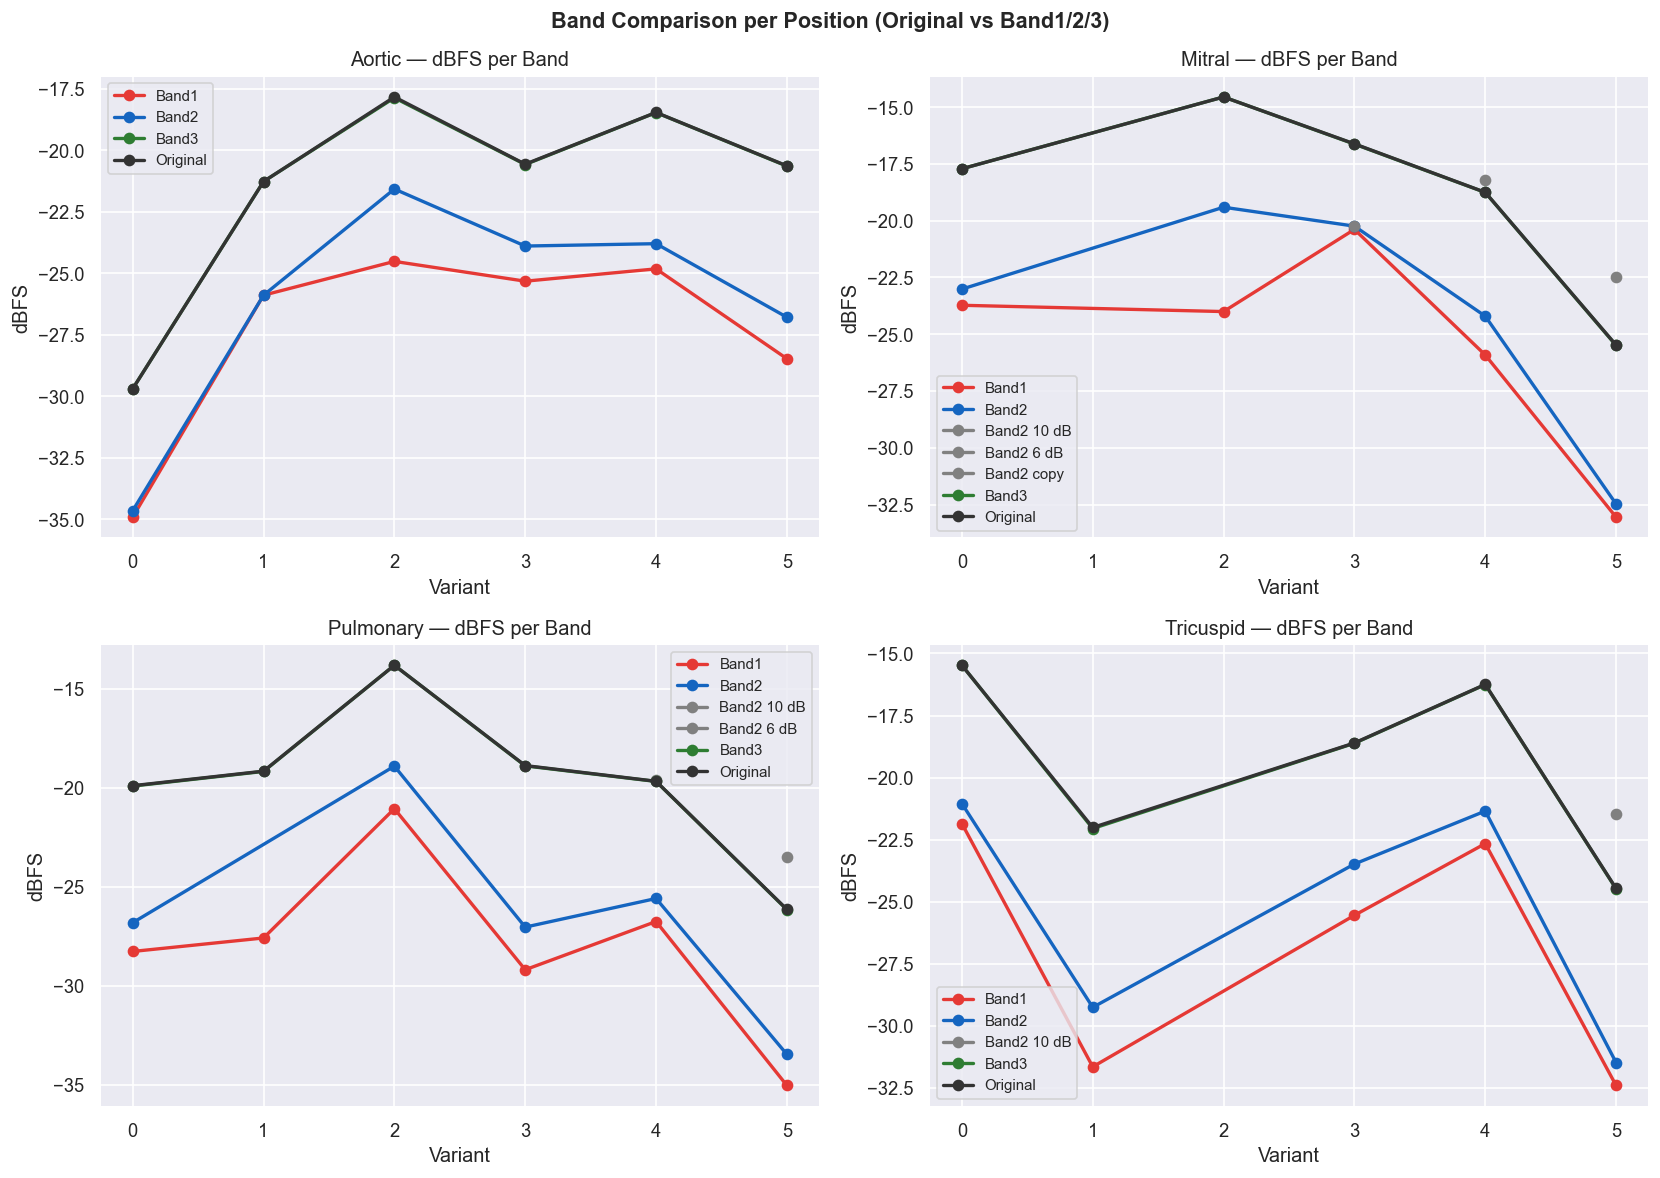

Saved: heart_sound_bands.png


In [9]:
# ==================== Visualization 2: Band comparison ====================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Band Comparison per Position (Original vs Band1/2/3)', fontsize=13, fontweight='bold')

band_colors = {'Original': '#333', 'Band1': '#E53935', 'Band2': '#1565C0', 'Band3': '#2E7D32'}

for ax, pos in zip(axes.flat, positions):
    sub = df[df['position'] == pos]
    for band, bdf in sub.groupby('band'):
        bdf = bdf.sort_values('variant')
        ax.plot(bdf['variant'], bdf['dbfs'], 'o-',
                label=band, color=band_colors.get(band, 'gray'), linewidth=2)
    ax.set_title(f'{pos} — dBFS per Band')
    ax.set_xlabel('Variant')
    ax.set_ylabel('dBFS')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('heart_sound_bands.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heart_sound_bands.png')

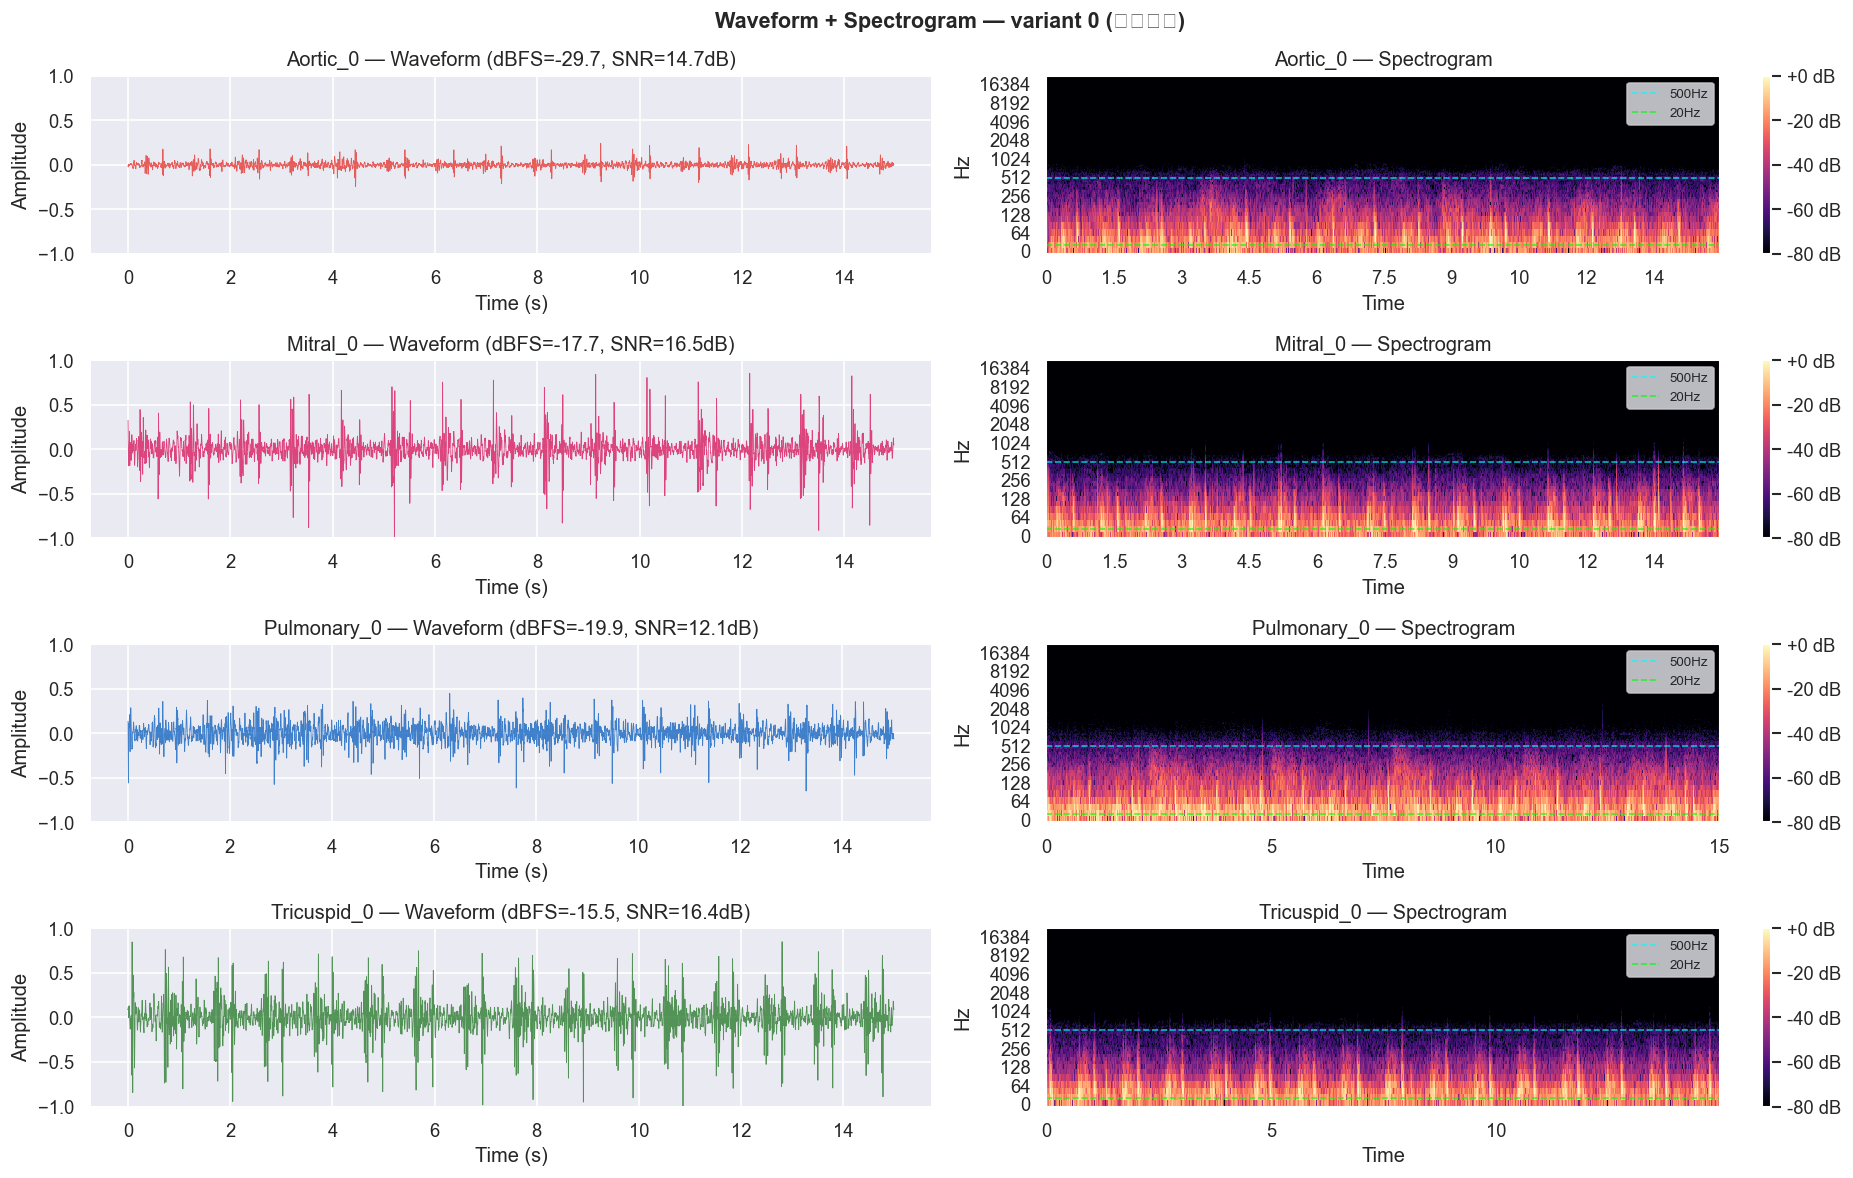

Saved: heart_sound_waveform.png


In [10]:
# ==================== Visualization 3: Waveform + Spectrogram ====================
# เลือก 4 ตัวอย่าง: ปกติ (variant=0) ของแต่ละตำแหน่ง

samples = df_orig[df_orig['variant'] == 0]

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Waveform + Spectrogram — variant 0 (ปกติ)', fontsize=13, fontweight='bold')

for i, (_, row) in enumerate(samples.iterrows()):
    y, sr = librosa.load(row['filepath'], sr=None, mono=True)
    
    # Waveform
    ax1 = fig.add_subplot(4, 2, i*2 + 1)
    t = np.linspace(0, len(y)/sr, len(y))
    ax1.plot(t, y, color=colors[i], linewidth=0.5, alpha=0.8)
    ax1.set_title(f"{row['position']}_0 — Waveform (dBFS={row['dbfs']:.1f}, SNR={row['snr_db']:.1f}dB)")
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude')
    ax1.set_ylim(-1, 1)
    
    # Spectrogram
    ax2 = fig.add_subplot(4, 2, i*2 + 2)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, y_axis='log', x_axis='time',
                              ax=ax2, cmap='magma')
    ax2.set_title(f"{row['position']}_0 — Spectrogram")
    ax2.axhline(y=500, color='cyan', linewidth=1, linestyle='--', alpha=0.7, label='500Hz')
    ax2.axhline(y=20, color='lime', linewidth=1, linestyle='--', alpha=0.7, label='20Hz')
    ax2.legend(fontsize=8, loc='upper right')
    plt.colorbar(ax2.collections[0], ax=ax2, format='%+2.0f dB')

plt.tight_layout()
plt.savefig('heart_sound_waveform.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heart_sound_waveform.png')

In [11]:
# ==================== Recommendation ====================

print('=' * 60)
print('RECOMMENDATION — ไฟล์ที่แนะนำสำหรับใช้ใน App')
print('=' * 60)

# เกณฑ์: SNR สูง + Low Freq % สูง + ความดังพอเหมาะ (dBFS > -30)
df_orig['score'] = (
    df_orig['snr_db'].rank(pct=True) * 0.4 +         # 40% SNR
    df_orig['low_freq_pct'].rank(pct=True) * 0.4 +   # 40% Low freq
    df_orig['dbfs'].rank(pct=True) * 0.2             # 20% ความดัง
)

print('\n📊 Top 3 ไฟล์ที่ดีที่สุดสำหรับ Demo (score สูงสุด):')
top = df_orig.nlargest(3, 'score')[['folder','dbfs','snr_db','low_freq_pct','score']]
for i, (_, row) in enumerate(top.iterrows(), 1):
    print(f'  {i}. {row["folder"]:20s}  dBFS={row["dbfs"]:6.1f}  SNR={row["snr_db"]:5.1f}dB  LowFreq={row["low_freq_pct"]:5.1f}%  Score={row["score"]:4.2f}')

print('\n🔇 ไฟล์ที่ noise เยอะที่สุด (ควรหลีกเลี่ยง):')
worst = df_orig.nsmallest(3, 'snr_db')[['folder','snr_db','noise_floor_db']]
for i, (_, row) in enumerate(worst.iterrows(), 1):
    print(f'  {i}. {row["folder"]:20s}  SNR={row["snr_db"]:5.1f}dB  Noise Floor={row["noise_floor_db"]:6.1f}dB')

print('\n🔊 ไฟล์ที่ดังสุด:')
loud = df_orig.nlargest(3, 'dbfs')[['folder','dbfs','peak_dbfs']]
for i, (_, row) in enumerate(loud.iterrows(), 1):
    print(f'  {i}. {row["folder"]:20s}  RMS={row["dbfs"]:6.1f}dBFS  Peak={row["peak_dbfs"]:6.1f}dBFS')

print('\n🔕 ไฟล์ที่เบาสุด:')
quiet = df_orig.nsmallest(3, 'dbfs')[['folder','dbfs','peak_dbfs']]
for i, (_, row) in enumerate(quiet.iterrows(), 1):
    print(f'  {i}. {row["folder"]:20s}  RMS={row["dbfs"]:6.1f}dBFS  Peak={row["peak_dbfs"]:6.1f}dBFS')

print('\n💓 ไฟล์ที่มีพลังงาน Low Freq (20-500Hz) มากสุด (เสียงหัวใจชัดที่สุด):')
heart = df_orig.nlargest(5, 'low_freq_pct')[['folder','low_freq_pct','snr_db','dbfs']]
for i, (_, row) in enumerate(heart.iterrows(), 1):
    print(f'  {i}. {row["folder"]:20s}  Low Freq={row["low_freq_pct"]:5.1f}%  SNR={row["snr_db"]:5.1f}dB  dBFS={row["dbfs"]:6.1f}')

RECOMMENDATION — ไฟล์ที่แนะนำสำหรับใช้ใน App

📊 Top 3 ไฟล์ที่ดีที่สุดสำหรับ Demo (score สูงสุด):
  1. Aortic_4              dBFS= -18.5  SNR= 24.6dB  LowFreq= 89.6%  Score=0.90
  2. Tricuspid_4           dBFS= -16.2  SNR= 26.0dB  LowFreq= 87.4%  Score=0.90
  3. Mitral_4              dBFS= -18.8  SNR= 20.2dB  LowFreq= 94.6%  Score=0.86

🔇 ไฟล์ที่ noise เยอะที่สุด (ควรหลีกเลี่ยง):
  1. Aortic_2              SNR= 11.6dB  Noise Floor= -25.3dB
  2. Aortic_1              SNR= 11.9dB  Noise Floor= -28.7dB
  3. Pulmonary_0           SNR= 12.1dB  Noise Floor= -27.7dB

🔊 ไฟล์ที่ดังสุด:
  1. Pulmonary_2           RMS= -13.8dBFS  Peak=   0.0dBFS
  2. Mitral_2              RMS= -14.6dBFS  Peak=   0.0dBFS
  3. Tricuspid_0           RMS= -15.5dBFS  Peak=  -0.0dBFS

🔕 ไฟล์ที่เบาสุด:
  1. Aortic_0              RMS= -29.7dBFS  Peak= -12.3dBFS
  2. Pulmonary_5           RMS= -26.1dBFS  Peak= -10.2dBFS
  3. Mitral_5              RMS= -25.5dBFS  Peak= -10.4dBFS

💓 ไฟล์ที่มีพลังงาน Low Freq (20-500Hz) มากสุ

In [12]:
# ==================== Export CSV ====================

out_path = 'heart_sound_analysis.csv'
df_orig[['folder','position','variant','dbfs','peak_dbfs','snr_db',
         'noise_floor_db','low_freq_pct','spectral_centroid_hz',
         'duration_s','sample_rate','score']]\
    .sort_values('score', ascending=False)\
    .to_csv(out_path, index=False)

print(f'Exported: {out_path}')
print(f'Total files analyzed: {len(df)} (รวมทุก band)')
print(f'Original.wav files: {len(df_orig)}')

Exported: heart_sound_analysis.csv
Total files analyzed: 93 (รวมทุก band)
Original.wav files: 22
